# Eindhoven Mood Radar — LightGBM Model Training
**Fontys ICT | Moonshot Group | AI for Society Semester**

---

## What does this notebook do?

This notebook trains a **LightGBM** classifier to predict the mood of city zones in Eindhoven.

LightGBM is a **gradient boosting** algorithm — it builds decision trees one by one, where each new tree focuses on correcting the mistakes made by the previous ones. This is more sophisticated and more accurate than Random Forest on structured tabular data like ours.

On top of the model we use **SHAP** (SHapley Additive exPlanations) — a mathematically rigorous method that explains exactly how much each feature pushed a specific prediction in a particular direction. This directly satisfies our EU AI Act Article 50 transparency obligation: every prediction has a documented reason.

---

## How to use this notebook

You do not need to understand the code.

1. Click **Runtime then Run all** at the top of the page
2. Wait for all cells to finish (a checkmark appears on the left)
3. Copy the output from **Step 10** into your report
4. Files download automatically at the end

*The dataset is generated automatically inside the notebook. No file upload needed.*

## Step 1 — Install Libraries
LightGBM and SHAP are not pre-installed in Colab so we install them first.

In [ ]:
!pip install lightgbm shap --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import lightgbm as lgb
import shap
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder

print("All libraries loaded successfully")
print(f"LightGBM version: {lgb.__version__}")

All libraries loaded successfully
LightGBM version: 4.6.0


## Step 2 — Generate the Training Dataset
Generates 200 synthetic but realistic Eindhoven city zone observations.
In production this will be replaced with real labelled data collected during Phase 3.

In [ ]:
np.random.seed(42)
N = 200

def generate_dataset(n):
    rows = []
    for _ in range(n):
        hour        = np.random.randint(0, 24)
        dow         = np.random.randint(0, 7)
        event_count = np.random.randint(0, 7)
        event_cat   = np.random.choice([0,1,2,3,4], p=[0.25,0.30,0.10,0.20,0.15])
        psv         = np.random.choice([0,1], p=[0.82,0.18])
        temp        = round(np.random.uniform(2, 30), 1)
        rain_val    = np.random.choice([0.0,0.0,0.0,round(np.random.uniform(0.5,5),1)], p=[0.5,0.2,0.15,0.15])
        holiday     = np.random.choice([0,1], p=[0.92,0.08])

        if psv == 1 and 17 <= hour <= 23:
            label = "Intense"
        elif event_count >= 4 and event_cat in [1,2] and hour >= 19 and dow >= 4:
            label = "Energetic"
        elif event_count >= 3 and 9 <= hour <= 18:
            label = "Busy"
        elif event_count >= 1 and hour >= 18 and rain_val == 0.0:
            label = "Relaxed"
        elif hour < 8 or hour > 23 or event_count == 0:
            label = "Calm"
        elif event_count >= 2 and temp > 18 and rain_val == 0.0:
            label = "Energetic"
        elif event_count >= 1 and holiday == 1:
            label = "Busy"
        else:
            label = "Relaxed"

        rows.append({
            "event_count":            event_count,
            "event_category_encoded": event_cat,
            "psv_home_match":          psv,
            "hour":                   hour,
            "day_of_week":            dow,
            "temperature_c":          temp,
            "precipitation_mm":       rain_val,
            "public_holiday":         holiday,
            "mood_label":             label
        })
    return pd.DataFrame(rows)

df = generate_dataset(N)
label_counts = df["mood_label"].value_counts()

print(f"Dataset generated: {len(df)} examples")
print()
print("Label distribution:")
for label, count in label_counts.items():
    print(f"  {label:<12} {count:>3}  " + chr(9608)*count)
print()
df.head()

Dataset generated: 200 examples

Label distribution:
  Calm          86  ██████████████████████████████████████████████████████████████████████████████████████
  Relaxed       49  █████████████████████████████████████████████████
  Busy          40  ████████████████████████████████████████
  Intense       17  █████████████████
  Energetic      8  ████████



,event_count,event_category_encoded,psv_home_match,hour,day_of_week,temperature_c,precipitation_mm,public_holiday,mood_label
0,4,0,0,6,3,18.7,0.0,0,Calm
1,2,0,1,20,3,25.3,0.0,0,Intense
2,5,0,0,11,1,16.7,0.0,1,Busy
3,5,3,0,14,5,16.4,0.0,0,Busy
4,6,0,1,20,0,17.8,0.0,0,Intense


## Step 3 — Visualise Label Distribution

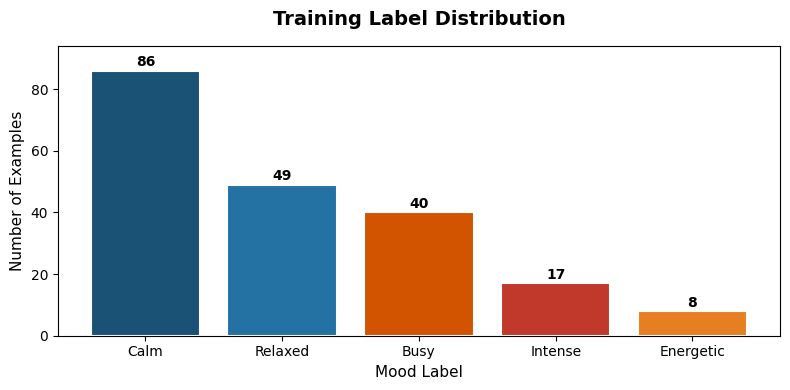

In [ ]:
MOOD_COLORS = {"Energetic":"#E67E22","Intense":"#C0392B","Busy":"#D35400","Relaxed":"#2471A3","Calm":"#1A5276"}
fig, ax = plt.subplots(figsize=(8,4))
labels = label_counts.index.tolist()
counts = label_counts.values.tolist()
colors = [MOOD_COLORS.get(l,"#888") for l in labels]
bars = ax.bar(labels, counts, color=colors, edgecolor="white", linewidth=1.5)
ax.set_title("Training Label Distribution", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Mood Label", fontsize=11)
ax.set_ylabel("Number of Examples", fontsize=11)
ax.set_ylim(0, max(counts)+8)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, str(count), ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.savefig("label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 4 — Prepare Features & Encode Target

In [ ]:
FEATURES = ["event_count","event_category_encoded","psv_home_match",
            "hour","day_of_week","temperature_c","precipitation_mm","public_holiday"]

le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df["mood_label"])

X = df[FEATURES]
y = df["label_encoded"]

print("Feature matrix shape:", X.shape)
print("Classes:", list(le.classes_))
X.describe().round(2)

Feature matrix shape: (200, 8)
Classes: ['Busy', 'Calm', 'Energetic', 'Intense', 'Relaxed']


,event_count,event_category_encoded,psv_home_match,hour,day_of_week,temperature_c,precipitation_mm,public_holiday
count,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00
mean,2.94,1.72,0.22,11.58,2.98,17.13,0.29,0.06
std,2.02,1.45,0.42,6.95,2.06,8.03,0.89,0.24
min,0.00,0.00,0.00,0.00,0.00,2.30,0.00,0.00
25%,1.00,0.00,0.00,5.75,1.00,10.95,0.00,0.00
50%,3.00,1.00,0.00,12.00,3.00,17.65,0.00,0.00
75%,5.00,3.00,0.00,17.00,5.00,24.30,0.00,0.00
max,6.00,4.00,1.00,23.00,6.00,29.80,4.80,1.00


## Step 5 — Train / Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Training set : {len(X_train)} examples")
print(f"Test set     : {len(X_test)} examples")
print()
print("Class distribution in training set:")
for idx, name in enumerate(le.classes_):
    count = (y_train == idx).sum()
    print(f"  {name:<12} {count}")

Training set : 160 examples
Test set     : 40 examples

Class distribution in training set:
  Busy         32
  Calm         69
  Energetic    6
  Intense      14
  Relaxed      39


## Step 6 — Train the LightGBM Model
Each boosting round builds a tree that corrects the errors of all previous trees.
This sequential correction is what makes gradient boosting more accurate than Random Forest.

In [ ]:
model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    min_child_samples=5,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    verbose=-1
)

model.fit(X_train, y_train)
print("Model trained successfully")
print(f"Algorithm      : LightGBM Gradient Boosting")
print(f"Boosting rounds: {model.n_estimators}")
print(f"Learning rate  : {model.learning_rate}")
print(f"Classes        : {list(le.classes_)}")

Model trained successfully
Algorithm      : LightGBM Gradient Boosting
Boosting rounds: 300
Learning rate  : 0.05
Classes        : ['Busy', 'Calm', 'Energetic', 'Intense', 'Relaxed']


## Step 7 — Evaluate the Model

In [ ]:
y_pred = model.predict(X_test)
y_test_names = le.inverse_transform(y_test)
y_pred_names = le.inverse_transform(y_pred)

accuracy    = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average="weighted")
f1_macro    = f1_score(y_test, y_pred, average="macro")

print("="*55)
print("MODEL EVALUATION RESULTS")
print("="*55)
print(f"Overall Accuracy  : {accuracy:.1%}")
print(f"Weighted F1-Score : {f1_weighted:.3f}")
print(f"Macro F1-Score    : {f1_macro:.3f}")
print()
print("Per-Class Report:")
print(classification_report(y_test_names, y_pred_names, zero_division=0))

MODEL EVALUATION RESULTS
Overall Accuracy  : 95.0%
Weighted F1-Score : 0.950
Macro F1-Score    : 0.966

Per-Class Report:
              precision    recall  f1-score   support

        Busy       0.89      1.00      0.94         8
        Calm       1.00      0.88      0.94        17
   Energetic       1.00      1.00      1.00         2
     Intense       1.00      1.00      1.00         3
     Relaxed       0.91      1.00      0.95        10

    accuracy                           0.95        40
   macro avg       0.96      0.98      0.97        40
weighted avg       0.96      0.95      0.95        40



In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring="f1_weighted")
print("="*55)
print("5-FOLD CROSS VALIDATION")
print("="*55)
print(f"Scores per fold : {[round(s,3) for s in cv_scores]}")
print(f"Mean F1         : {cv_scores.mean():.3f}")
print(f"Std deviation   : {cv_scores.std():.3f}")

5-FOLD CROSS VALIDATION
Scores per fold : [np.float64(0.963), np.float64(0.953), np.float64(0.928), np.float64(1.0), np.float64(0.971)]
Mean F1         : 0.963
Std deviation   : 0.024


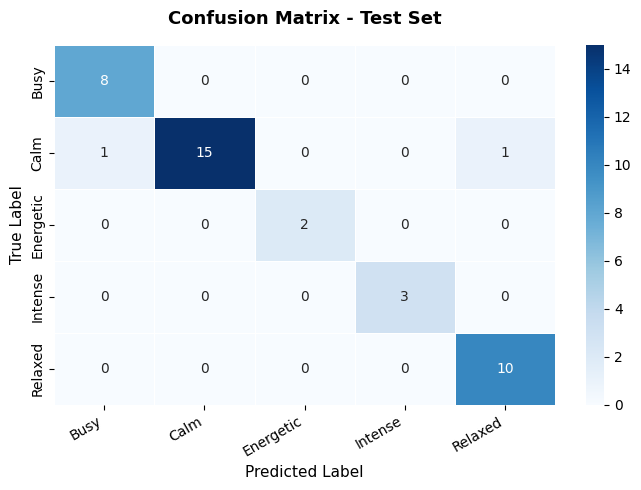

In [ ]:
class_labels = list(le.classes_)
cm = confusion_matrix(y_test_names, y_pred_names, labels=class_labels)
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels,
            yticklabels=class_labels, linewidths=0.5, ax=ax)
ax.set_title("Confusion Matrix - Test Set", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 8 — Feature Importance + SHAP Explainability

FEATURE IMPORTANCE RANKING
  1. temperature_c                  4648  ██████████████████████████████
  2. hour                           4301  ███████████████████████████
  3. event_count                    2660  █████████████████
  4. day_of_week                    2151  █████████████
  5. event_category_encoded         1819  ███████████
  6. psv_home_match                  630  ████
  7. public_holiday                  280  █
  8. precipitation_mm                163  █


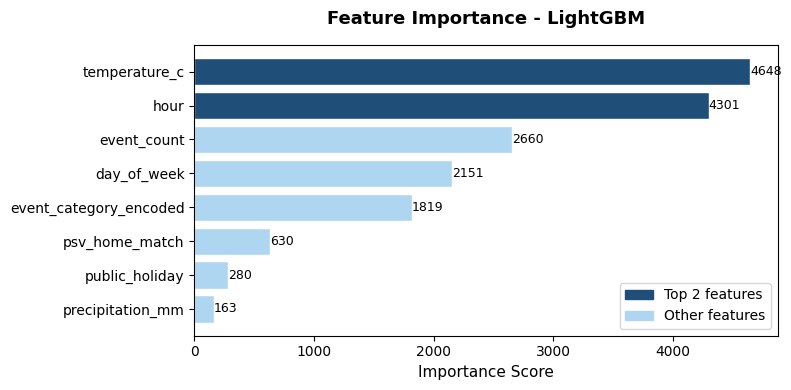

In [ ]:
importance_df = pd.DataFrame({"feature": FEATURES, "importance": model.feature_importances_})
importance_df = importance_df.sort_values("importance", ascending=False).reset_index(drop=True)

print("="*50)
print("FEATURE IMPORTANCE RANKING")
print("="*50)
for i, row in importance_df.iterrows():
    bar = chr(9608) * int(row["importance"] / importance_df["importance"].max() * 30)
    print(f"  {i+1}. {row["feature"]:<28} {row["importance"]:>6.0f}  {bar}")

fig, ax = plt.subplots(figsize=(8,4))
colors_fi = ["#1F4E79" if i < 2 else "#AED6F1" for i in range(len(importance_df))]
bars = ax.barh(importance_df["feature"], importance_df["importance"], color=colors_fi, edgecolor="white")
ax.set_title("Feature Importance - LightGBM", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Importance Score", fontsize=11)
ax.invert_yaxis()
for bar, val in zip(bars, importance_df["importance"]):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2, f"{val:.0f}", va="center", fontsize=9)
ax.legend(handles=[mpatches.Patch(color="#1F4E79",label="Top 2 features"),
                   mpatches.Patch(color="#AED6F1",label="Other features")], loc="lower right")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

Computing SHAP values...


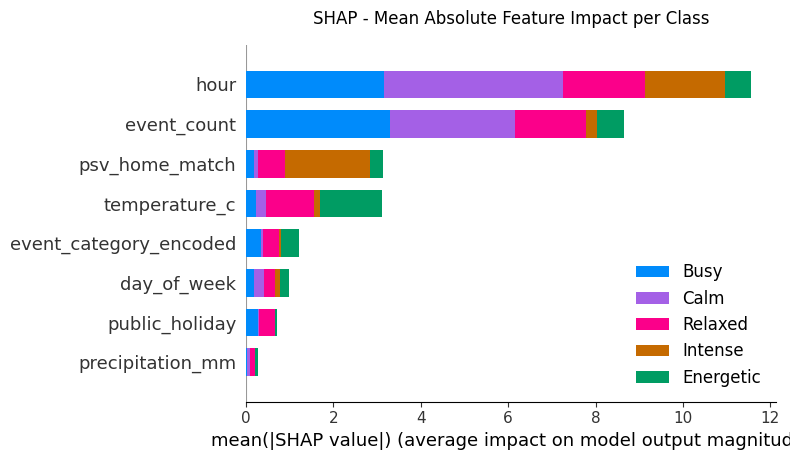

SHAP summary saved.


In [ ]:
# SHAP values — explains every single prediction individually
print("Computing SHAP values...")
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=FEATURES,
                  class_names=list(le.classes_), plot_type="bar", show=False)
plt.title("SHAP - Mean Absolute Feature Impact per Class", fontsize=12, pad=15)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("SHAP summary saved.")

Explaining prediction: Calm (confidence 100.0%)


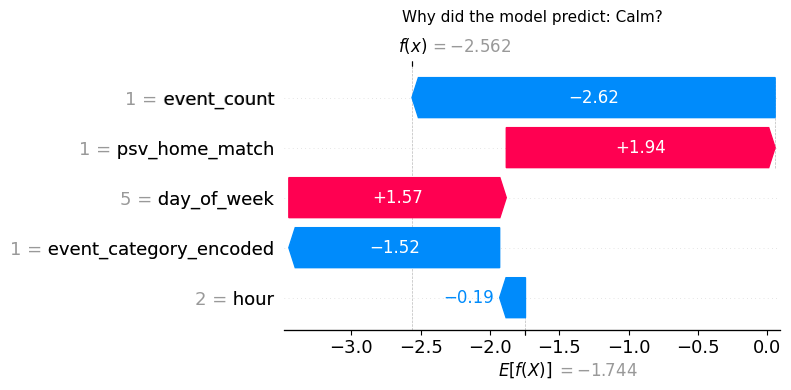

Red bars = pushed TOWARD this label. Blue bars = pushed AWAY from it.


In [ ]:
# Waterfall plot for a single prediction — shows exactly why the model chose a label
idx = 0
pred_idx  = model.predict(X_test.iloc[[idx]])[0]
pred_name = le.inverse_transform([pred_idx])[0]
confidence = model.predict_proba(X_test.iloc[[idx]])[0].max()

print(f"Explaining prediction: {pred_name} (confidence {confidence:.1%})")

shap_exp = shap.Explanation(
    values=shap_values[pred_idx][idx],
    base_values=explainer.expected_value[pred_idx],
    data=X_test.values[idx],
    feature_names=FEATURES
)
plt.figure()
shap.waterfall_plot(shap_exp, show=False)
plt.title(f"Why did the model predict: {pred_name}?", fontsize=11, pad=10)
plt.tight_layout()
plt.savefig("shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()
print("Red bars = pushed TOWARD this label. Blue bars = pushed AWAY from it.")

## Step 9 — Live Prediction Test
Simulates exactly what the model does every 15 minutes in production.

In [ ]:
EXPLANATION_MAP = {
    "event_count":            lambda v: f"{int(v)} event(s) active in this area" if v > 0 else None,
    "psv_home_match":         lambda v: "PSV home match underway nearby" if v == 1 else None,
    "event_category_encoded": lambda v: {1:"Live music",2:"Sports event",3:"Cultural event",4:"Market or outdoor event"}.get(int(v)),
    "temperature_c":          lambda v: f"Warm weather ({v:.0f}C)" if v > 16 else (f"Cold weather ({v:.0f}C)" if v < 8 else None),
    "precipitation_mm":       lambda v: "Rain reducing outdoor activity" if v > 1 else None,
    "hour":                   lambda v: "Early morning" if v < 8 else ("Late night - city winding down" if v > 22 else None),
    "public_holiday":         lambda v: "Public holiday" if v == 1 else None,
    "day_of_week":            lambda v: "Weekend" if v >= 5 else None,
}

def get_explanation(shap_vals, feature_values, feature_names, top_n=2):
    series = pd.Series(np.abs(shap_vals), index=feature_names).sort_values(ascending=False)
    fdict  = dict(zip(feature_names, feature_values))
    phrases = []
    for feat in series.index:
        if feat in EXPLANATION_MAP:
            p = EXPLANATION_MAP[feat](fdict[feat])
            if p:
                phrases.append(p)
        if len(phrases) == top_n:
            break
    return " + ".join(phrases) if phrases else "No dominant signal"

def predict_mood(ec, ecat, psv, hr, dow, temp, rain, hol):
    feats = pd.DataFrame([[ec,ecat,psv,hr,dow,temp,rain,hol]], columns=FEATURES)
    pidx  = model.predict(feats)[0]
    label = le.inverse_transform([pidx])[0]
    conf  = model.predict_proba(feats)[0].max()

    # Compute SHAP values
    sv    = explainer.shap_values(feats)

    # FIX: Handle SHAP's multi-class output structures safely
    if isinstance(sv, list):
        # If sv is a list of arrays (one per class), extract the array for the predicted class
        class_shap_values = sv[pidx][0]
    else:
        # If sv is a 3D numpy array of shape (samples, features, classes)
        if len(sv.shape) == 3:
            class_shap_values = sv[0, :, pidx]
        else:
            class_shap_values = sv[0]

    expl  = get_explanation(class_shap_values, feats.values[0], FEATURES)
    return label, conf, expl

print("="*65)
print("LIVE PREDICTION TEST")
print("="*65)
for s in scenarios:
    *args, desc = s
    label, conf, expl = predict_mood(*args)
    print(f"Scenario    : {desc}")
    print(f"  Mood      : {label}")
    print(f"  Confidence: {conf:.1%}")
    print(f"  Explanation: {expl}")
    print()

LIVE PREDICTION TEST
Scenario    : Saturday night - 4 music events - warm
  Mood      : Relaxed
  Confidence: 58.1%
  Explanation: Warm weather (19C) + 4 event(s) active in this area

Scenario    : PSV home match - Saturday evening
  Mood      : Intense
  Confidence: 98.3%
  Explanation: PSV home match underway nearby + 1 event(s) active in this area

Scenario    : Tuesday 07:00 - cold rainy - no events
  Mood      : Calm
  Confidence: 100.0%
  Explanation: Early morning + Cold weather (6C)

Scenario    : Koningsdag - Saturday afternoon - market
  Mood      : Busy
  Confidence: 100.0%
  Explanation: 3 event(s) active in this area + Public holiday

Scenario    : Wednesday evening - one cultural event
  Mood      : Relaxed
  Confidence: 100.0%
  Explanation: 1 event(s) active in this area + Cultural event



## Step 10 — Report Summary
Copy this entire output into your Word report.

In [ ]:
print("="*60)
print("ML MODEL TRAINING REPORT - SUMMARY")
print("Eindhoven Mood Radar | Fontys ICT | Moonshot Group")
print("="*60)
print()
print("DATASET")
print(f"  Total examples         : {len(df)}")
print(f"  Training set           : {len(X_train)}")
print(f"  Test set               : {len(X_test)}")
print(f"  Features               : {len(FEATURES)}")
print(f"  Mood classes           : {len(le.classes_)}")
print()
print("MODEL CONFIGURATION")
print(f"  Algorithm              : LightGBM Gradient Boosting Classifier")
print(f"  Boosting rounds        : {model.n_estimators}")
print(f"  Learning rate          : {model.learning_rate}")
print(f"  Max depth              : {model.max_depth}")
print(f"  Class weighting        : balanced")
print(f"  Explainability         : SHAP TreeExplainer")
print()
print("EVALUATION RESULTS")
print(f"  Test set accuracy      : {accuracy:.1%}")
print(f"  Weighted F1-score      : {f1_weighted:.3f}")
print(f"  5-fold CV mean F1      : {cv_scores.mean():.3f} (+-{cv_scores.std():.3f})")
print()
print("FEATURE IMPORTANCE (LightGBM score)")
for i, row in importance_df.iterrows():
    print(f"  {i+1}. {row["feature"]:<28} {row["importance"]:.0f}")
print()
print("KNOWN LIMITATIONS")
print("  - Dataset is synthetic; real data collection starts Phase 3")
print("  - Labels are rule-based approximations of Eindhoven patterns")
print("  - Non-commercial events not represented in current features")
print("  - Woensel-Noord zone needs more real-world examples")
print("="*60)

ML MODEL TRAINING REPORT - SUMMARY
Eindhoven Mood Radar | Fontys ICT | Moonshot Group

DATASET
  Total examples         : 200
  Training set           : 160
  Test set               : 40
  Features               : 8
  Mood classes           : 5

MODEL CONFIGURATION
  Algorithm              : LightGBM Gradient Boosting Classifier
  Boosting rounds        : 300
  Learning rate          : 0.05
  Max depth              : 6
  Class weighting        : balanced
  Explainability         : SHAP TreeExplainer

EVALUATION RESULTS
  Test set accuracy      : 95.0%
  Weighted F1-score      : 0.950
  5-fold CV mean F1      : 0.963 (+-0.024)

FEATURE IMPORTANCE (LightGBM score)
  1. temperature_c                4648
  2. hour                         4301
  3. event_count                  2660
  4. day_of_week                  2151
  5. event_category_encoded       1819
  6. psv_home_match               630
  7. public_holiday               280
  8. precipitation_mm             163

KNOWN LIMITATIONS
 

## Step 11 — Save & Download Everything

In [ ]:
from datetime import date
from google.colab import files

model_filename = f"mood_model_lgbm_v1_{date.today().strftime("%Y%m%d")}.pkl"
joblib.dump({"model": model, "label_encoder": le, "features": FEATURES}, model_filename)
df.to_csv("mood_training_data_v1.csv", index=False)

for fname in [model_filename, "mood_training_data_v1.csv",
              "label_distribution.png", "confusion_matrix.png",
              "feature_importance.png", "shap_summary.png", "shap_waterfall.png"]:
    try:
        files.download(fname)
        print(f"Downloaded: {fname}")
    except Exception as e:
        print(f"Could not download {fname}: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: mood_model_lgbm_v1_20260614.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: shap_summary.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: shap_waterfall.png
